# Setup and Data

## Import Required Libraries

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd

# Plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Nonlinear dimensionality reduction
from sklearn.manifold import TSNE
from umap import UMAP

# Variational Autoencoder
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Density-based clustering
from sklearn.cluster import DBSCAN

# Internal clustering evaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

## Set Plotting Style and Random Seeds

In [2]:
# Use Seaborn whitegrid style for clear and consistent figures
sns.set_theme(style="whitegrid")

# Use a dark color palette so plotted points and lines are clearly visible
sns.set_palette("deep")

# Set a consistent figure size and resolution
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 120

# Set one random seed for reproducible results
RANDOM_STATE = 42

# Reproducibility for Python, NumPy, and PyTorch
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Also seed CUDA when a GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


## Set Project Folder Paths

In [3]:
# Move two levels upward from notebooks/module_2 to the project root
ROOT = Path.cwd().parents[1]

# Prepared clustering dataset created in the dataset creation notebook
DATASET_DIR = ROOT / "results" / "module_2" / "dataset_creation"

# Common output folders for the three clustering techniques
RESULTS_DIR = ROOT / "results" / "module_2" / "2.dim_clustering"
PLOTS_DIR = ROOT / "plots" / "module_2" / "2.dim_clustering"

# Separate result folders for each dimensionality reduction technique
TSNE_RESULTS_DIR = RESULTS_DIR / "tsne"
UMAP_RESULTS_DIR = RESULTS_DIR / "umap"
VAE_RESULTS_DIR = RESULTS_DIR / "vae"

# Separate plot folders for each dimensionality reduction technique
TSNE_PLOTS_DIR = PLOTS_DIR / "tsne"
UMAP_PLOTS_DIR = PLOTS_DIR / "umap"
VAE_PLOTS_DIR = PLOTS_DIR / "vae"

# Create all output folders if they do not already exist
for folder in [
    TSNE_RESULTS_DIR, UMAP_RESULTS_DIR, VAE_RESULTS_DIR,
    TSNE_PLOTS_DIR, UMAP_PLOTS_DIR, VAE_PLOTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Dataset folder:", DATASET_DIR)
print("Results folder:", RESULTS_DIR)
print("Plots folder:", PLOTS_DIR)

Project root: C:\Users\samsa\Documents\ICU Clustering
Dataset folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\2.dim_clustering
Plots folder: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\2.dim_clustering


## Load the Scaled Clustering Dataset

In [4]:
# Final Min-Max scaled dataset created during dataset preparation
SCALED_DATA_PATH = DATASET_DIR / "clustering_dataset_scaled.csv"

# Load the patient-level scaled clustering dataset
scaled_df = pd.read_csv(SCALED_DATA_PATH)

print("Scaled dataset shape:", scaled_df.shape)

# Preview the first five rows
scaled_df.head()

Scaled dataset shape: (7859, 81)


,patientunitstayid,age,gender,admissionheight,admissionweight,BUN_min,Hgb_min,WBC x 1000_min,anion gap_min,bicarbonate_min,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,0.0,0.271546,0.077035,0.055777,0.283237,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,165269,0.486111,1.0,0.267434,0.057636,0.143426,0.364162,0.042126,0.410714,0.219512,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,0.0,0.254770,0.061000,0.183267,0.410405,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,0.0,0.275658,0.075577,0.039841,0.705202,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,215156,0.680556,0.0,0.250658,0.065598,0.135458,0.398844,0.013386,0.464286,0.390244,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Load the Clustering Feature Names

In [5]:
# Saved list of features used to build the clustering matrix
FEATURE_NAMES_PATH = DATASET_DIR / "clustering_feature_names.csv"

# Load the saved clustering feature names
feature_names_df = pd.read_csv(FEATURE_NAMES_PATH)

# Convert the first column into a Python list of feature names
feature_cols = feature_names_df.iloc[:, 0].astype(str).tolist()

print("Number of clustering features:", len(feature_cols))

# Preview the first ten feature names
feature_cols

Number of clustering features: 80


['age',
 'gender',
 'admissionheight',
 'admissionweight',
 'BUN_min',
 'Hgb_min',
 'WBC x 1000_min',
 'anion gap_min',
 'bicarbonate_min',
 'chloride_min',
 'creatinine_min',
 'glucose_min',
 'lactate_min',
 'platelets x 1000_min',
 'potassium_min',
 'sodium_min',
 'BUN_max',
 'Hgb_max',
 'WBC x 1000_max',
 'anion gap_max',
 'bicarbonate_max',
 'chloride_max',
 'creatinine_max',
 'glucose_max',
 'lactate_max',
 'platelets x 1000_max',
 'potassium_max',
 'sodium_max',
 'BUN_mean',
 'Hgb_mean',
 'WBC x 1000_mean',
 'anion gap_mean',
 'bicarbonate_mean',
 'chloride_mean',
 'creatinine_mean',
 'glucose_mean',
 'lactate_mean',
 'platelets x 1000_mean',
 'potassium_mean',
 'sodium_mean',
 'BUN_std',
 'Hgb_std',
 'WBC x 1000_std',
 'anion gap_std',
 'bicarbonate_std',
 'chloride_std',
 'creatinine_std',
 'glucose_std',
 'lactate_std',
 'platelets x 1000_std',
 'potassium_std',
 'sodium_std',
 'lab_measurement_count',
 'sao2_fpc_1',
 'sao2_fpc_2',
 'sao2_fpc_3',
 'sao2_fpc_4',
 'sao2_fpc_5',


## Prepare the Clustering Matrix

In [6]:
# Select only the saved clustering features in the correct order
X = scaled_df[feature_cols].copy()

# Convert the feature matrix to NumPy for model input
X_matrix = X.to_numpy()

print("Clustering matrix shape:", X_matrix.shape)
print("Number of patients:", X_matrix.shape[0])
print("Number of features:", X_matrix.shape[1])

Clustering matrix shape: (7859, 80)
Number of patients: 7859
Number of features: 80


## Verify the Clustering Matrix

In [7]:
# Check that patient identifiers are unique
print("Unique patient IDs:", scaled_df["patientunitstayid"].nunique())
print("Duplicate patient IDs:", scaled_df["patientunitstayid"].duplicated().sum())

# Confirm the clustering matrix contains no missing or infinite values
print("Missing values:", np.isnan(X_matrix).sum())
print("Infinite values:", np.isinf(X_matrix).sum())

# Confirm Min-Max scaled feature values remain approximately between 0 and 1
print("Minimum feature value:", X_matrix.min())
print("Maximum feature value:", X_matrix.max())

# Confirm that the selected feature order matches the saved feature list
print("Feature order matches saved feature list:", list(X.columns) == feature_cols)

Unique patient IDs: 7859
Duplicate patient IDs: 0
Missing values: 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002
Feature order matches saved feature list: True


# Two-Dimensional Representations

## t-SNE Representation

### Set Final t-SNE Parameters

In [8]:
# Final t-SNE settings selected during hyperparameter tuning
TSNE_COMPONENTS = 2
TSNE_PERPLEXITY = 80
TSNE_METRIC = "euclidean"
TSNE_INIT = "pca"
TSNE_LEARNING_RATE = "auto"
TSNE_MAX_ITER = 1000

print("t-SNE components:", TSNE_COMPONENTS)
print("t-SNE perplexity:", TSNE_PERPLEXITY)
print("t-SNE metric:", TSNE_METRIC)
print("t-SNE initialization:", TSNE_INIT)
print("t-SNE learning rate:", TSNE_LEARNING_RATE)
print("t-SNE maximum iterations:", TSNE_MAX_ITER)
print("Random seed:", RANDOM_STATE)

t-SNE components: 2
t-SNE perplexity: 80
t-SNE metric: euclidean
t-SNE initialization: pca
t-SNE learning rate: auto
t-SNE maximum iterations: 1000
Random seed: 42


### Generate the t-SNE Embedding

In [9]:
# Create the t-SNE model using the selected final parameters
tsne_model = TSNE(
    n_components=TSNE_COMPONENTS,
    perplexity=TSNE_PERPLEXITY,
    metric=TSNE_METRIC,
    init=TSNE_INIT,
    learning_rate=TSNE_LEARNING_RATE,
    max_iter=TSNE_MAX_ITER,
    random_state=RANDOM_STATE
)

# Transform the original clustering matrix into two dimensions
tsne_embedding = tsne_model.fit_transform(X_matrix)

print("t-SNE embedding shape:", tsne_embedding.shape)

t-SNE embedding shape: (7859, 2)


### Create the t-SNE Results Table

In [10]:
# Store patient IDs together with their 2D t-SNE coordinates
tsne_results = pd.DataFrame({
    "patientunitstayid": scaled_df["patientunitstayid"].values,
    "tsne_1": tsne_embedding[:, 0],
    "tsne_2": tsne_embedding[:, 1]
})

print("t-SNE results shape:", tsne_results.shape)

# Preview the first five patients
tsne_results.head()

t-SNE results shape: (7859, 3)


,patientunitstayid,tsne_1,tsne_2
0,151900,-53.001102,-20.004972
1,165269,-54.509876,8.362201
2,179269,18.713709,-26.751606
3,172764,23.752241,-29.727482
4,215156,20.175079,-18.988346


### Plot the t-SNE Representation

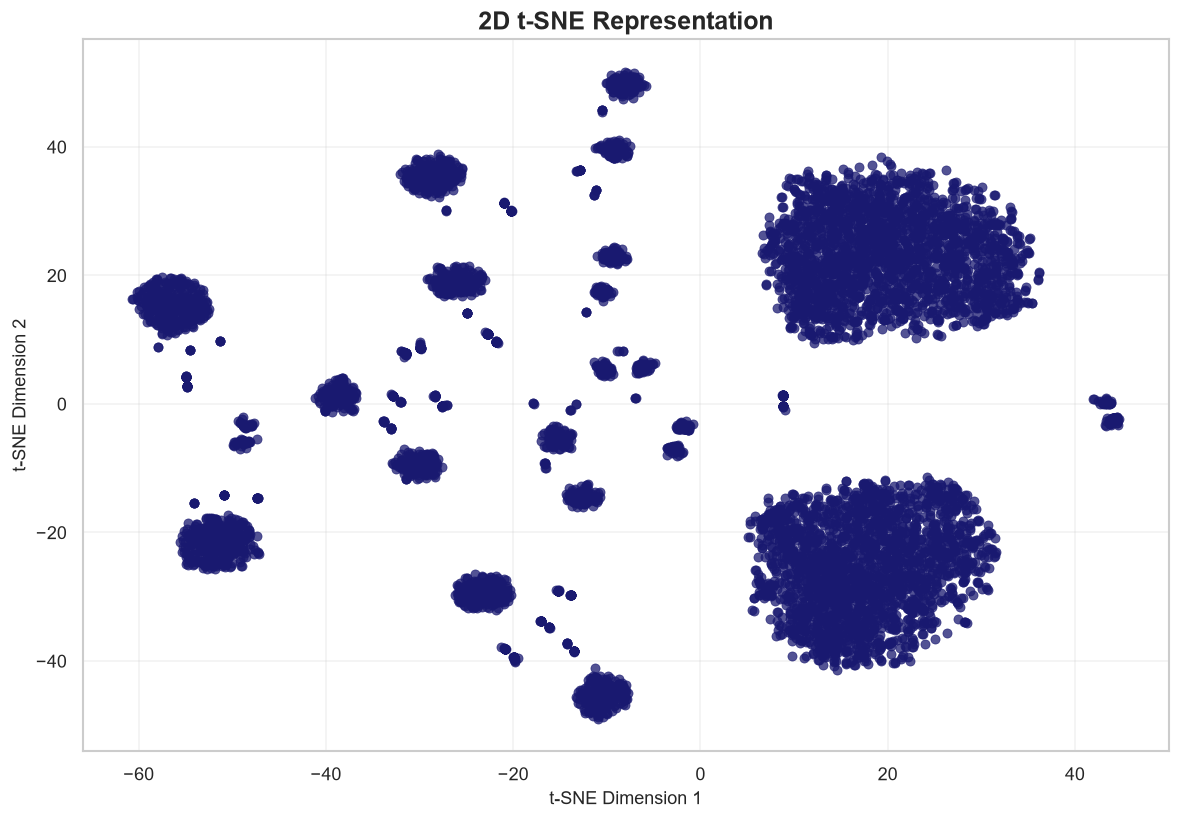

In [11]:
# Plot the 2D t-SNE embedding before DBSCAN clustering
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=tsne_results,
    x="tsne_1",
    y="tsne_2",
    color="midnightblue",   # Dark color for clear visibility
    s=30,                   # Point size
    alpha=0.75,             # Slight transparency for overlapping points
    edgecolor=None
)

# Add clear title and axis labels
plt.title("2D t-SNE Representation", fontsize=15, fontweight="bold")
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

# Keep the whitegrid background clean
plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the representation plot
plt.savefig(
    TSNE_PLOTS_DIR / "tsne_representation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## UMAP Representation

### Set Final UMAP Parameters

In [12]:
# Final UMAP settings selected during hyperparameter tuning
UMAP_COMPONENTS = 2
UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "euclidean"

print("UMAP components:", UMAP_COMPONENTS)
print("UMAP n_neighbors:", UMAP_N_NEIGHBORS)
print("UMAP min_dist:", UMAP_MIN_DIST)
print("UMAP metric:", UMAP_METRIC)
print("Random seed:", RANDOM_STATE)

UMAP components: 2
UMAP n_neighbors: 10
UMAP min_dist: 0.1
UMAP metric: euclidean
Random seed: 42


### Generate the UMAP Embedding

In [13]:
# Create the UMAP model using the selected final parameters
umap_model = UMAP(
    n_components=UMAP_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE,
    n_jobs = 1
)

# Transform the original clustering matrix into two dimensions
umap_embedding = umap_model.fit_transform(X_matrix)

print("UMAP embedding shape:", umap_embedding.shape)

UMAP embedding shape: (7859, 2)


### Create the UMAP Results Table

In [14]:
# Store patient IDs together with their 2D UMAP coordinates
umap_results = pd.DataFrame({
    "patientunitstayid": scaled_df["patientunitstayid"].values,
    "umap_1": umap_embedding[:, 0],
    "umap_2": umap_embedding[:, 1]
})

print("UMAP results shape:", umap_results.shape)

# Preview the first five patients
umap_results.head()

UMAP results shape: (7859, 3)


,patientunitstayid,umap_1,umap_2
0,151900,23.310844,7.567116
1,165269,18.234638,3.835096
2,179269,11.107013,15.826281
3,172764,10.809042,16.510021
4,215156,11.142427,14.751802


### Plot the UMAP Representation

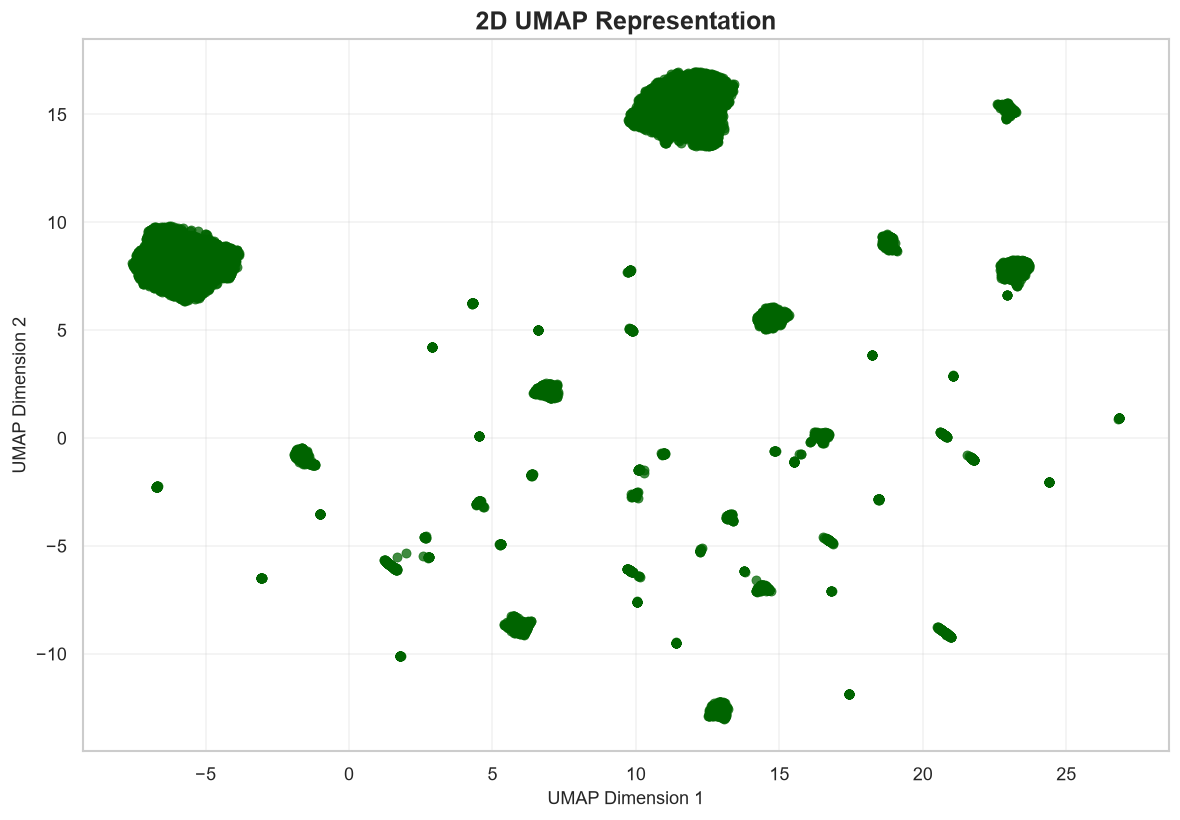

In [15]:
# Plot the 2D UMAP embedding before DBSCAN clustering
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=umap_results,
    x="umap_1",
    y="umap_2",
    color="darkgreen",      # Dark color for clear visibility
    s=30,                   # Point size
    alpha=0.75,             # Slight transparency for overlapping points
    edgecolor=None
)

# Add clear title and axis labels
plt.title("2D UMAP Representation", fontsize=15, fontweight="bold")
plt.xlabel("UMAP Dimension 1", fontsize=11)
plt.ylabel("UMAP Dimension 2", fontsize=11)

# Keep the whitegrid background clean
plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the representation plot
plt.savefig(
    UMAP_PLOTS_DIR / "umap_representation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## VAE Representation

### Set Final VAE Parameters

In [16]:
# Final VAE settings selected during hyperparameter tuning
VAE_HIDDEN_DIMS = (256, 128)
VAE_LATENT_DIM = 2
VAE_LEARNING_RATE = 0.0001
VAE_BETA = 0.1
VAE_BATCH_SIZE = 128
VAE_EPOCHS = 50

print("VAE hidden layers:", VAE_HIDDEN_DIMS)
print("VAE latent dimensions:", VAE_LATENT_DIM)
print("VAE learning rate:", VAE_LEARNING_RATE)
print("VAE beta:", VAE_BETA)
print("VAE batch size:", VAE_BATCH_SIZE)
print("VAE epochs:", VAE_EPOCHS)

VAE hidden layers: (256, 128)
VAE latent dimensions: 2
VAE learning rate: 0.0001
VAE beta: 0.1
VAE batch size: 128
VAE epochs: 50


### Prepare the Data for PyTorch

In [17]:
# Convert the clustering matrix to a PyTorch float tensor
X_tensor = torch.tensor(X_matrix, dtype=torch.float32)

# Create a dataset containing only the input features
vae_dataset = TensorDataset(X_tensor)

# Create mini-batches for VAE training
vae_loader = DataLoader(
    vae_dataset,
    batch_size=VAE_BATCH_SIZE,
    shuffle=True
)

print("PyTorch tensor shape:", X_tensor.shape)
print("Number of training batches:", len(vae_loader))

PyTorch tensor shape: torch.Size([7859, 80])
Number of training batches: 62


### Define the VAE Architecture

In [18]:
# Number of input features in the clustering matrix
VAE_INPUT_DIM = X_matrix.shape[1]


class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        hidden_1, hidden_2 = hidden_dims

        # Encoder: reduce the original features into a compact representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU()
        )

        # Learn the mean and log-variance of the 2D latent distribution
        self.fc_mu = nn.Linear(hidden_2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_2, latent_dim)

        # Decoder: reconstruct the original features from the latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, input_dim),
            nn.Sigmoid()   # Appropriate because input features are Min-Max scaled
        )

    def reparameterize(self, mu, logvar):
        # Sample a latent representation while allowing gradient-based training
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + epsilon * std

    def forward(self, x):
        # Encode the input features
        encoded = self.encoder(x)

        # Obtain latent distribution parameters
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)

        # Sample the latent representation
        z = self.reparameterize(mu, logvar)

        # Reconstruct the original input
        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar

##### Structure of VAE :
```
Input Features
      ↓
256 neurons
      ↓
128 neurons
      ↓
2D Latent Space
      ↓
128 neurons
      ↓
256 neurons
      ↓
Reconstructed Features
```

### Create the VAE Model

In [19]:
# Use GPU when available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the VAE using the selected architecture
vae_model = VAE(
    input_dim=VAE_INPUT_DIM,
    hidden_dims=VAE_HIDDEN_DIMS,
    latent_dim=VAE_LATENT_DIM
).to(device)

print("Device:", device)
print(vae_model)

Device: cuda
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=80, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=80, bias=True)
    (5): Sigmoid()
  )
)


### Define the VAE Loss Function and Optimizer

In [20]:
# Mean Squared Error measures how well the decoder reconstructs the input
reconstruction_loss_fn = nn.MSELoss(reduction="sum")

# Adam optimizer updates the VAE parameters during training
optimizer = torch.optim.Adam(
    vae_model.parameters(),
    lr=VAE_LEARNING_RATE
)


def vae_loss(reconstructed, original, mu, logvar):
    # Reconstruction loss keeps the decoded output close to the original input
    reconstruction_loss = reconstruction_loss_fn(
        reconstructed,
        original
    )

    # KL divergence regularizes the latent space
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Beta controls the strength of latent-space regularization
    total_loss = reconstruction_loss + VAE_BETA * kl_loss

    return total_loss

##### Observation :

```
Reconstruction Loss
        +
Beta × KL Divergence
        ↓
Total VAE Loss
```

### Train the VAE

In [21]:
# Store the average training loss from each epoch
training_losses = []

# Train the VAE for the selected number of epochs
for epoch in range(VAE_EPOCHS):

    vae_model.train()
    total_loss = 0

    for (batch_x,) in vae_loader:

        # Move the current batch to the selected device
        batch_x = batch_x.to(device)

        # Reset gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass through the VAE
        reconstructed, mu, logvar = vae_model(batch_x)

        # Calculate the total VAE loss
        loss = vae_loss(
            reconstructed,
            batch_x,
            mu,
            logvar
        )

        # Backpropagation and parameter update
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Calculate average loss per patient for the current epoch
    average_loss = total_loss / len(vae_dataset)
    training_losses.append(average_loss)

    # Print progress every 10 epochs and at the first epoch
    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:02d}/{VAE_EPOCHS} "
            f"- Loss: {average_loss:.4f}"
        )

Epoch 01/50 - Loss: 8.7470
Epoch 10/50 - Loss: 1.5837
Epoch 20/50 - Loss: 1.5261
Epoch 30/50 - Loss: 1.3123
Epoch 40/50 - Loss: 1.1437
Epoch 50/50 - Loss: 1.0898


### Plot the VAE Training Loss

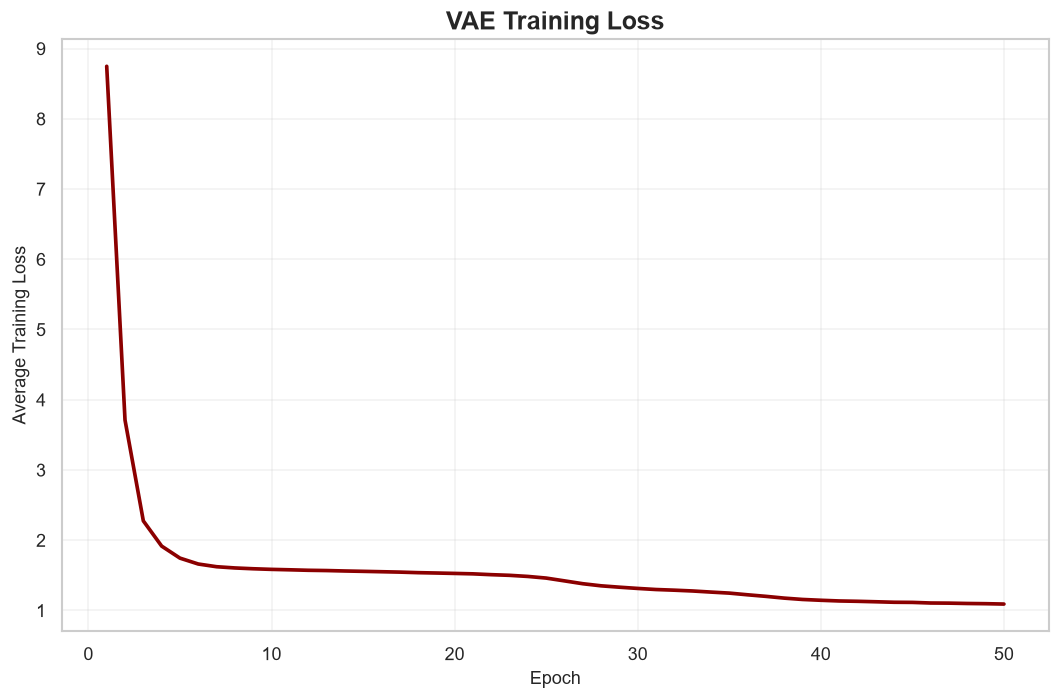

In [22]:
# Create an epoch sequence for the x-axis
epochs = range(1, VAE_EPOCHS + 1)

# Plot the training loss across epochs
plt.figure(figsize=(9, 6))

sns.lineplot(
    x=list(epochs),
    y=training_losses,
    color="darkred",
    linewidth=2.2
)

# Add clear title and axis labels
plt.title("VAE Training Loss", fontsize=15, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Average Training Loss", fontsize=11)

# Keep the whitegrid background clean
plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the training-loss figure
plt.savefig(
    VAE_PLOTS_DIR / "vae_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Extract the 2D VAE Latent Representation

In [23]:
# Switch the model to evaluation mode
vae_model.eval()

# Disable gradient calculation because training is finished
with torch.no_grad():

    # Move the full dataset to the selected device
    X_device = X_tensor.to(device)

    # Encode the input features
    encoded = vae_model.encoder(X_device)

    # Use the latent mean as the stable 2D patient representation
    vae_embedding = vae_model.fc_mu(encoded).cpu().numpy()

print("VAE embedding shape:", vae_embedding.shape)

VAE embedding shape: (7859, 2)


### Create the VAE Results Table

In [24]:
# Store patient IDs together with their 2D VAE latent coordinates
vae_results = pd.DataFrame({
    "patientunitstayid": scaled_df["patientunitstayid"].values,
    "vae_1": vae_embedding[:, 0],
    "vae_2": vae_embedding[:, 1]
})

print("VAE results shape:", vae_results.shape)

# Preview the first five patients
vae_results.head()

VAE results shape: (7859, 3)


,patientunitstayid,vae_1,vae_2
0,151900,-0.739029,0.245873
1,165269,0.179993,-0.184683
2,179269,-0.047939,1.596679
3,172764,-0.107191,1.551750
4,215156,-0.061609,1.603174


### Plot the VAE Representation

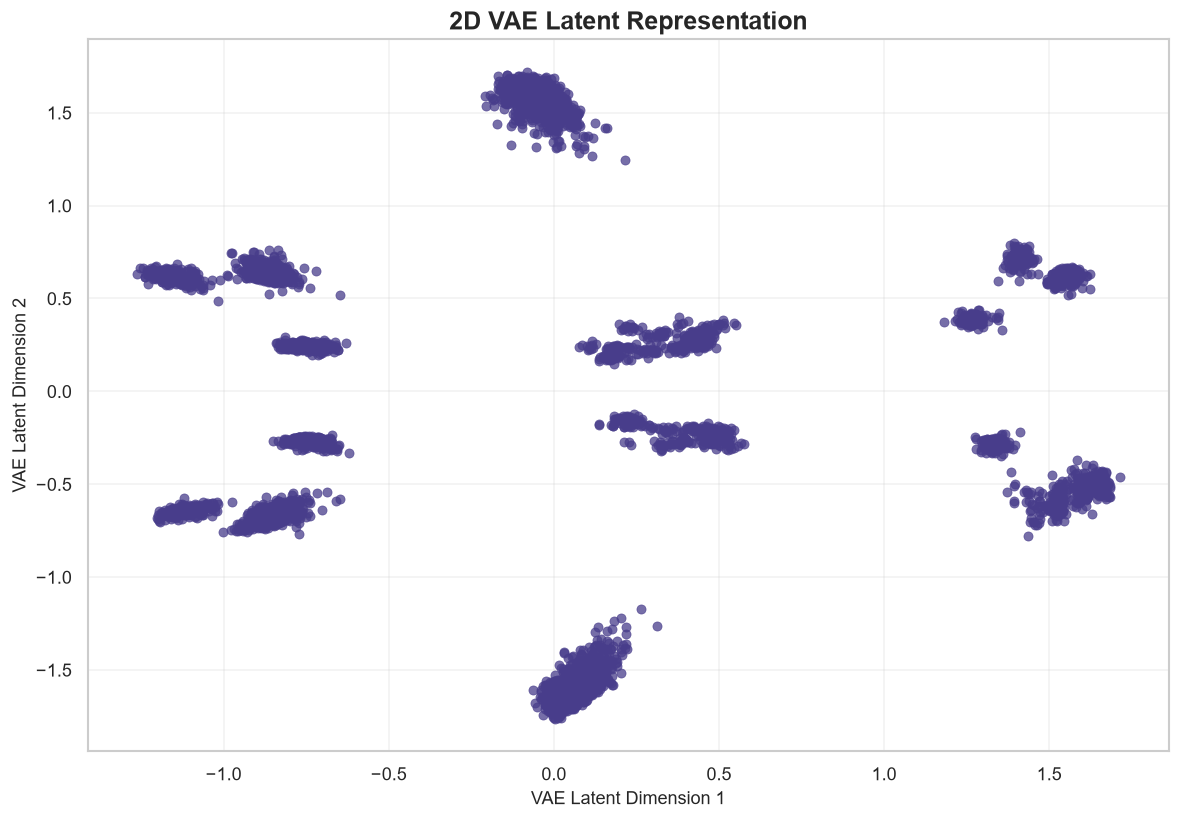

In [25]:
# Plot the 2D VAE latent representation before DBSCAN clustering
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=vae_results,
    x="vae_1",
    y="vae_2",
    color="darkslateblue",   # Dark color for clear visibility
    s=30,                    # Point size
    alpha=0.75,              # Slight transparency for overlapping points
    edgecolor=None
)

# Add clear title and axis labels
plt.title("2D VAE Latent Representation", fontsize=15, fontweight="bold")
plt.xlabel("VAE Latent Dimension 1", fontsize=11)
plt.ylabel("VAE Latent Dimension 2", fontsize=11)

# Keep the whitegrid background clean
plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the representation plot
plt.savefig(
    VAE_PLOTS_DIR / "vae_representation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# DBSCAN Clustering

## t-SNE + DBSCAN

### Set Final DBSCAN Parameters

In [26]:
# Final DBSCAN settings selected for the t-SNE embedding
TSNE_DBSCAN_EPS = 3.0
TSNE_DBSCAN_MIN_SAMPLES = 40
TSNE_DBSCAN_METRIC = "euclidean"

print("t-SNE DBSCAN epsilon:", TSNE_DBSCAN_EPS)
print("t-SNE DBSCAN minimum samples:", TSNE_DBSCAN_MIN_SAMPLES)
print("t-SNE DBSCAN metric:", TSNE_DBSCAN_METRIC)

t-SNE DBSCAN epsilon: 3.0
t-SNE DBSCAN minimum samples: 40
t-SNE DBSCAN metric: euclidean


### Apply DBSCAN to the t-SNE Embedding

In [27]:
# Create the DBSCAN model for the t-SNE representation
tsne_dbscan = DBSCAN(
    eps=TSNE_DBSCAN_EPS,
    min_samples=TSNE_DBSCAN_MIN_SAMPLES,
    metric=TSNE_DBSCAN_METRIC
)

# Apply DBSCAN to the two t-SNE coordinates
tsne_clusters = tsne_dbscan.fit_predict(
    tsne_results[["tsne_1", "tsne_2"]]
)

# Add the cluster labels to the t-SNE results table
tsne_results["cluster"] = tsne_clusters

# Preview the updated results
tsne_results.head()

,patientunitstayid,tsne_1,tsne_2,cluster
0,151900,-53.001102,-20.004972,0
1,165269,-54.509876,8.362201,-1
2,179269,18.713709,-26.751606,1
3,172764,23.752241,-29.727482,1
4,215156,20.175079,-18.988346,1


### Summarize the t-SNE + DBSCAN Clustering Result

In [28]:
# Count the actual clusters, excluding DBSCAN outliers labeled as -1
tsne_cluster_labels = tsne_results["cluster"].unique()
tsne_n_clusters = len(tsne_cluster_labels[tsne_cluster_labels != -1])

# Count DBSCAN outliers
tsne_n_outliers = (tsne_results["cluster"] == -1).sum()

# Calculate the outlier percentage
tsne_outlier_pct = (
    tsne_n_outliers / len(tsne_results)
) * 100

print("t-SNE + DBSCAN Summary")
print("----------------------")
print("Number of patients:", len(tsne_results))
print("Number of clusters:", tsne_n_clusters)
print("Number of outliers:", tsne_n_outliers)
print(f"Outlier percentage: {tsne_outlier_pct:.2f}%")

t-SNE + DBSCAN Summary
----------------------
Number of patients: 7859
Number of clusters: 22
Number of outliers: 341
Outlier percentage: 4.34%


### Check t-SNE Cluster Sizes

In [29]:
# Count the number of patients assigned to each DBSCAN cluster
tsne_cluster_sizes = (
    tsne_results["cluster"]
    .value_counts()
    .sort_index()
)

print("t-SNE + DBSCAN Cluster Sizes")
print("----------------------------")
print(tsne_cluster_sizes)

t-SNE + DBSCAN Cluster Sizes
----------------------------
cluster
-1      341
 0      367
 1     2114
 2     2195
 3      354
 4       98
 5      229
 6      175
 7       94
 8      175
 9       73
 10     232
 11     139
 12     131
 13     119
 14     119
 15      95
 16      49
 17     110
 18     141
 19     243
 20     208
 21      58
Name: count, dtype: int64


### Plot the t-SNE + DBSCAN Clusters

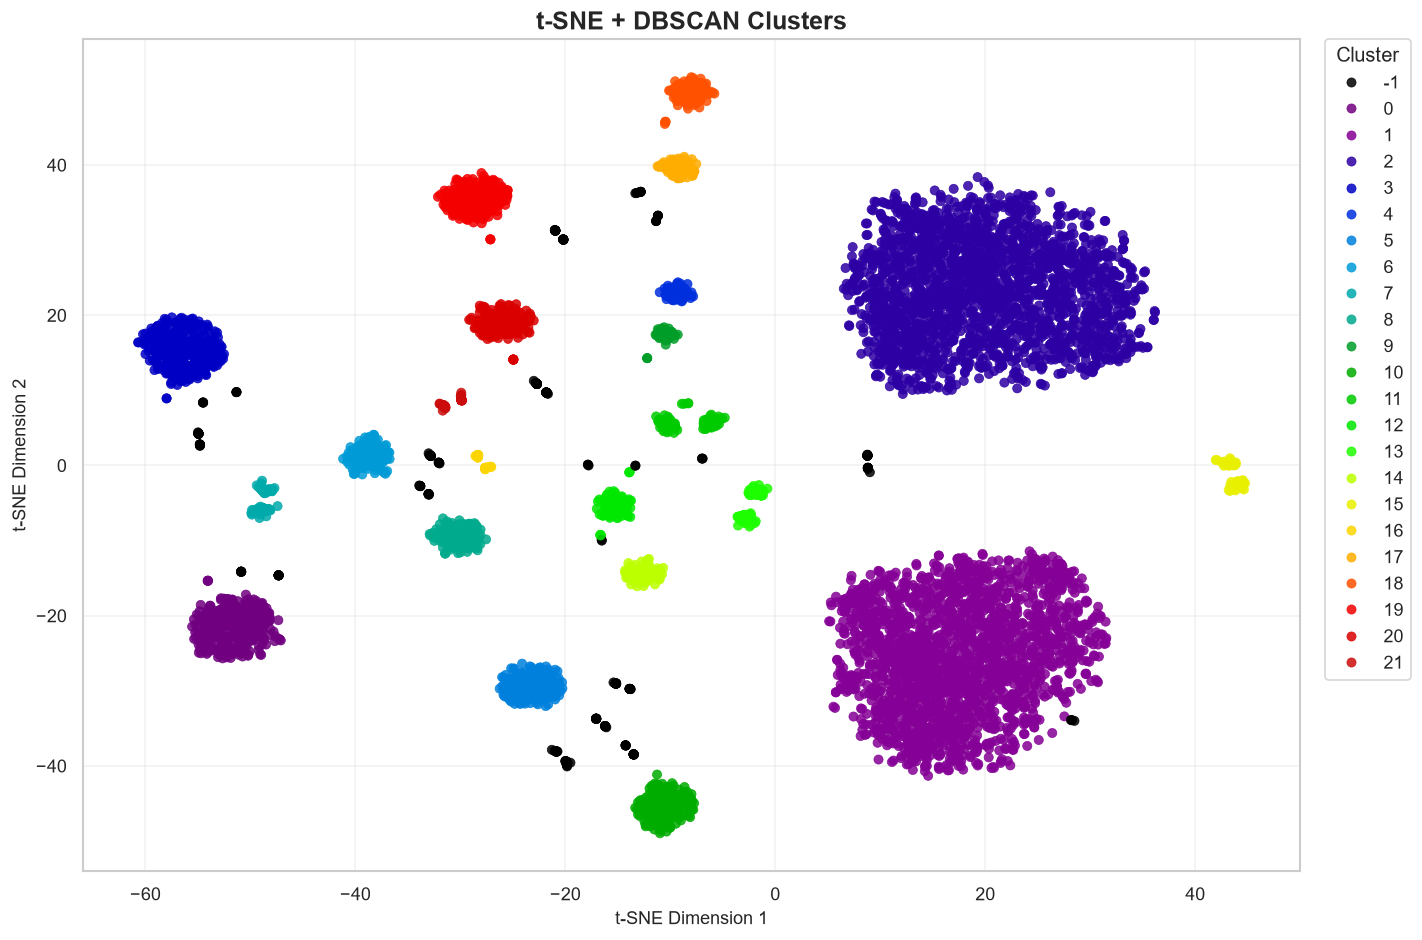

In [30]:
# Get the actual cluster labels and keep DBSCAN outliers (-1) separate
tsne_cluster_ids = sorted(
    cluster for cluster in tsne_results["cluster"].unique()
    if cluster != -1
)

# Generate a distinct color for each identified cluster
tsne_colors = plt.cm.nipy_spectral(
    np.linspace(0.05, 0.95, len(tsne_cluster_ids))
)

# Map each cluster to its own color
tsne_palette = {
    cluster: color
    for cluster, color in zip(tsne_cluster_ids, tsne_colors)
}

# Display DBSCAN outliers in black
if -1 in tsne_results["cluster"].values:
    tsne_palette[-1] = "black"

# Plot the t-SNE embedding using DBSCAN cluster assignments
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=tsne_results,
    x="tsne_1",
    y="tsne_2",
    hue="cluster",
    palette=tsne_palette,
    s=30,
    alpha=0.85,
    edgecolor=None
)

# Add clear title and axis labels
plt.title("t-SNE + DBSCAN Clusters", fontsize=15, fontweight="bold")
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

# Place the cluster legend outside the figure for readability
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the final t-SNE + DBSCAN cluster plot
plt.savefig(
    TSNE_PLOTS_DIR / "tsne_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## UMAP + DBSCAN

### Set Final DBSCAN Parameters

In [31]:
# Final DBSCAN settings selected for the UMAP embedding
UMAP_DBSCAN_EPS = 0.35
UMAP_DBSCAN_MIN_SAMPLES = 50
UMAP_DBSCAN_METRIC = "euclidean"

print("UMAP DBSCAN epsilon:", UMAP_DBSCAN_EPS)
print("UMAP DBSCAN minimum samples:", UMAP_DBSCAN_MIN_SAMPLES)
print("UMAP DBSCAN metric:", UMAP_DBSCAN_METRIC)

UMAP DBSCAN epsilon: 0.35
UMAP DBSCAN minimum samples: 50
UMAP DBSCAN metric: euclidean


### Apply DBSCAN to the UMAP Embedding

In [32]:
# Create the DBSCAN model for the UMAP representation
umap_dbscan = DBSCAN(
    eps=UMAP_DBSCAN_EPS,
    min_samples=UMAP_DBSCAN_MIN_SAMPLES,
    metric=UMAP_DBSCAN_METRIC
)

# Apply DBSCAN to the two UMAP coordinates
umap_clusters = umap_dbscan.fit_predict(
    umap_results[["umap_1", "umap_2"]]
)

# Add the cluster labels to the UMAP results table
umap_results["cluster"] = umap_clusters

# Preview the updated results
umap_results.head()

,patientunitstayid,umap_1,umap_2,cluster
0,151900,23.310844,7.567116,0
1,165269,18.234638,3.835096,-1
2,179269,11.107013,15.826281,1
3,172764,10.809042,16.510021,1
4,215156,11.142427,14.751802,1


### Summarize the UMAP + DBSCAN Clustering Result

In [33]:
# Count the actual clusters, excluding DBSCAN outliers labeled as -1
umap_cluster_labels = umap_results["cluster"].unique()
umap_n_clusters = len(umap_cluster_labels[umap_cluster_labels != -1])

# Count DBSCAN outliers
umap_n_outliers = (umap_results["cluster"] == -1).sum()

# Calculate the outlier percentage
umap_outlier_pct = (
    umap_n_outliers / len(umap_results)
) * 100

print("UMAP + DBSCAN Summary")
print("---------------------")
print("Number of patients:", len(umap_results))
print("Number of clusters:", umap_n_clusters)
print("Number of outliers:", umap_n_outliers)
print(f"Outlier percentage: {umap_outlier_pct:.2f}%")

UMAP + DBSCAN Summary
---------------------
Number of patients: 7859
Number of clusters: 22
Number of outliers: 546
Outlier percentage: 6.95%


### Check UMAP Cluster Sizes

In [34]:
# Count the number of patients assigned to each DBSCAN cluster
umap_cluster_sizes = (
    umap_results["cluster"]
    .value_counts()
    .sort_index()
)

print("UMAP + DBSCAN Cluster Sizes")
print("---------------------------")
print(umap_cluster_sizes)

UMAP + DBSCAN Cluster Sizes
---------------------------
cluster
-1      546
 0      363
 1     2118
 2     2195
 3      352
 4       98
 5      229
 6      175
 7      175
 8       74
 9      232
 10      72
 11      51
 12     122
 13      60
 14      65
 15      65
 16     119
 17      57
 18     111
 19     139
 20     240
 21     201
Name: count, dtype: int64


### Plot the UMAP + DBSCAN Clusters

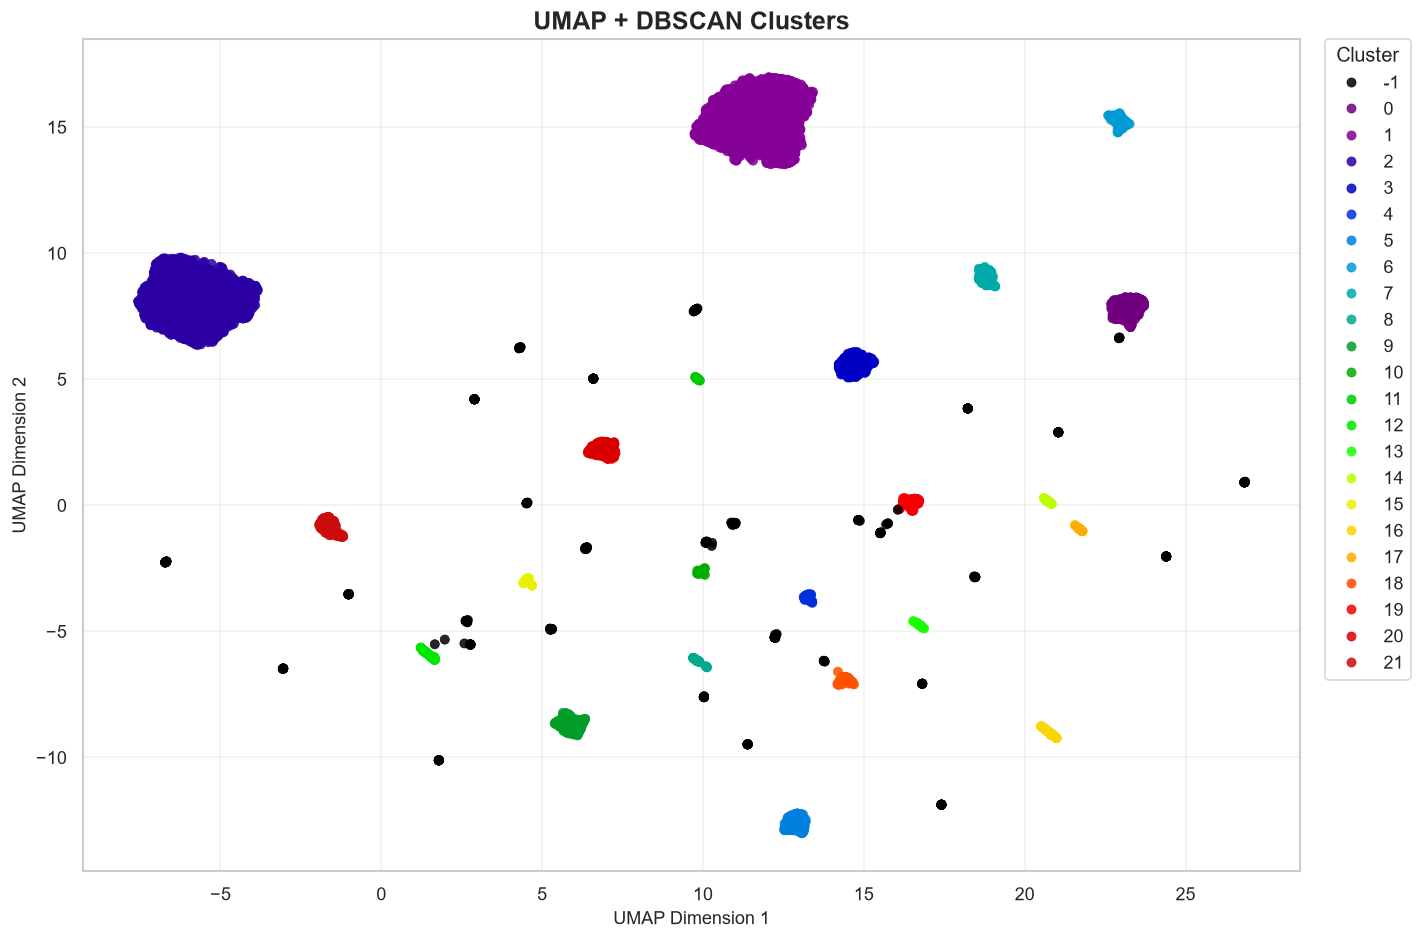

In [35]:
# Get the actual cluster labels and keep DBSCAN outliers (-1) separate
umap_cluster_ids = sorted(
    cluster for cluster in umap_results["cluster"].unique()
    if cluster != -1
)

# Generate a distinct color for each identified cluster
umap_colors = plt.cm.nipy_spectral(
    np.linspace(0.05, 0.95, len(umap_cluster_ids))
)

# Map each cluster to its own color
umap_palette = {
    cluster: color
    for cluster, color in zip(umap_cluster_ids, umap_colors)
}

# Display DBSCAN outliers in black
if -1 in umap_results["cluster"].values:
    umap_palette[-1] = "black"

# Plot the UMAP embedding using DBSCAN cluster assignments
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=umap_results,
    x="umap_1",
    y="umap_2",
    hue="cluster",
    palette=umap_palette,
    s=30,
    alpha=0.85,
    edgecolor=None
)

# Add clear title and axis labels
plt.title("UMAP + DBSCAN Clusters", fontsize=15, fontweight="bold")
plt.xlabel("UMAP Dimension 1", fontsize=11)
plt.ylabel("UMAP Dimension 2", fontsize=11)

# Place the cluster legend outside the figure for readability
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the final UMAP + DBSCAN cluster plot
plt.savefig(
    UMAP_PLOTS_DIR / "umap_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## VAE + DBSCAN

### Set Final DBSCAN Parameters

In [36]:
# Final DBSCAN settings selected for the VAE latent representation
VAE_DBSCAN_EPS = 0.20
VAE_DBSCAN_MIN_SAMPLES = 50
VAE_DBSCAN_METRIC = "euclidean"

print("VAE DBSCAN epsilon:", VAE_DBSCAN_EPS)
print("VAE DBSCAN minimum samples:", VAE_DBSCAN_MIN_SAMPLES)
print("VAE DBSCAN metric:", VAE_DBSCAN_METRIC)

VAE DBSCAN epsilon: 0.2
VAE DBSCAN minimum samples: 50
VAE DBSCAN metric: euclidean


### Apply DBSCAN to the VAE Embedding

In [37]:
# Create the DBSCAN model for the VAE latent representation
vae_dbscan = DBSCAN(
    eps=VAE_DBSCAN_EPS,
    min_samples=VAE_DBSCAN_MIN_SAMPLES,
    metric=VAE_DBSCAN_METRIC
)

# Apply DBSCAN to the two VAE latent coordinates
vae_clusters = vae_dbscan.fit_predict(
    vae_results[["vae_1", "vae_2"]]
)

# Add the cluster labels to the VAE results table
vae_results["cluster"] = vae_clusters

# Preview the updated results
vae_results.head()

,patientunitstayid,vae_1,vae_2,cluster
0,151900,-0.739029,0.245873,0
1,165269,0.179993,-0.184683,1
2,179269,-0.047939,1.596679,2
3,172764,-0.107191,1.551750,2
4,215156,-0.061609,1.603174,2


### Summarize the VAE + DBSCAN Clustering Result

In [38]:
# Count the actual clusters, excluding DBSCAN outliers labeled as -1
vae_cluster_labels = vae_results["cluster"].unique()
vae_n_clusters = len(vae_cluster_labels[vae_cluster_labels != -1])

# Count DBSCAN outliers
vae_n_outliers = (vae_results["cluster"] == -1).sum()

# Calculate the outlier percentage
vae_outlier_pct = (
    vae_n_outliers / len(vae_results)
) * 100

print("VAE + DBSCAN Summary")
print("--------------------")
print("Number of patients:", len(vae_results))
print("Number of clusters:", vae_n_clusters)
print("Number of outliers:", vae_n_outliers)
print(f"Outlier percentage: {vae_outlier_pct:.2f}%")

VAE + DBSCAN Summary
--------------------
Number of patients: 7859
Number of clusters: 10
Number of outliers: 0
Outlier percentage: 0.00%


### Check VAE Cluster Sizes

In [39]:
# Count the number of patients assigned to each DBSCAN cluster
vae_cluster_sizes = (
    vae_results["cluster"]
    .value_counts()
    .sort_index()
)

print("VAE + DBSCAN Cluster Sizes")
print("--------------------------")
print(vae_cluster_sizes)

VAE + DBSCAN Cluster Sizes
--------------------------
cluster
0     363
1     262
2    2118
3    2195
4     352
5     658
6     278
7     528
8     523
9     582
Name: count, dtype: int64


### Plot the VAE + DBSCAN Clusters

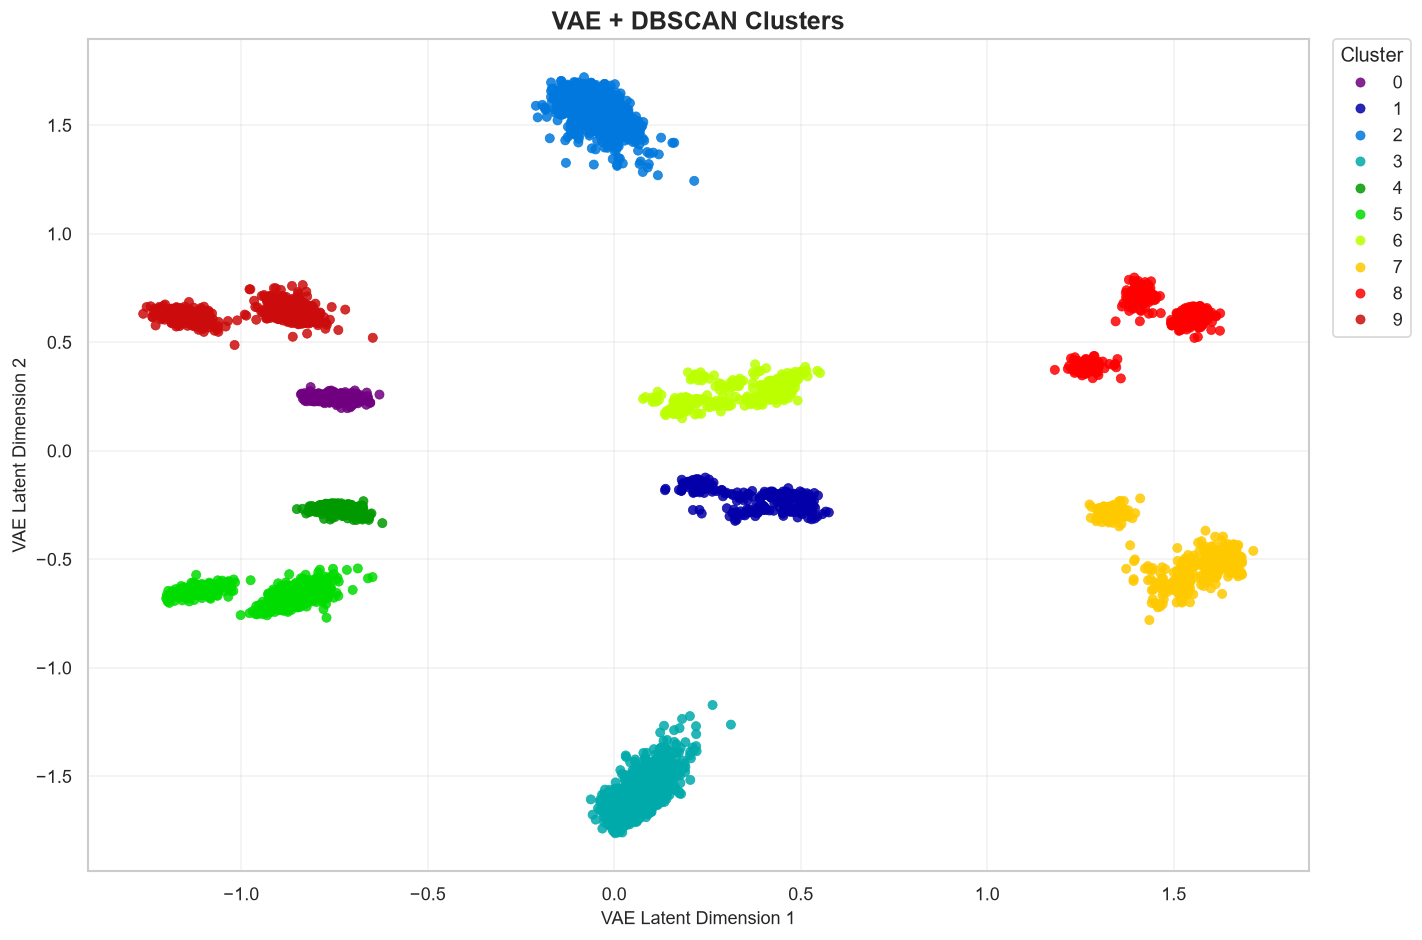

In [40]:
# Get the actual cluster labels and keep DBSCAN outliers (-1) separate
vae_cluster_ids = sorted(
    cluster for cluster in vae_results["cluster"].unique()
    if cluster != -1
)

# Generate a distinct color for each identified cluster
vae_colors = plt.cm.nipy_spectral(
    np.linspace(0.05, 0.95, len(vae_cluster_ids))
)

# Map each cluster to its own color
vae_palette = {
    cluster: color
    for cluster, color in zip(vae_cluster_ids, vae_colors)
}

# Display DBSCAN outliers in black
if -1 in vae_results["cluster"].values:
    vae_palette[-1] = "black"

# Plot the VAE latent space using DBSCAN cluster assignments
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=vae_results,
    x="vae_1",
    y="vae_2",
    hue="cluster",
    palette=vae_palette,
    s=30,
    alpha=0.85,
    edgecolor=None
)

# Add clear title and axis labels
plt.title("VAE + DBSCAN Clusters", fontsize=15, fontweight="bold")
plt.xlabel("VAE Latent Dimension 1", fontsize=11)
plt.ylabel("VAE Latent Dimension 2", fontsize=11)

# Place the cluster legend outside the figure for readability
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.grid(True, alpha=0.25)
plt.tight_layout()

# Save the final VAE + DBSCAN cluster plot
plt.savefig(
    VAE_PLOTS_DIR / "vae_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Internal Cluster Evaluation

## Evaluate t-SNE + DBSCAN

### Remove DBSCAN Outliers for Evaluation

In [41]:
# Keep only patients assigned to actual t-SNE clusters
tsne_eval = tsne_results[
    tsne_results["cluster"] != -1
].copy()

# Extract the 2D coordinates and cluster labels for evaluation
X_tsne_eval = tsne_eval[["tsne_1", "tsne_2"]].to_numpy()
y_tsne_eval = tsne_eval["cluster"].to_numpy()

print("Patients used for t-SNE evaluation:", len(tsne_eval))
print("Outliers excluded:", tsne_n_outliers)

Patients used for t-SNE evaluation: 7518
Outliers excluded: 341


### Calculate t-SNE Internal Evaluation Metrics

In [42]:
# Calculate internal clustering quality metrics for t-SNE + DBSCAN
tsne_silhouette = silhouette_score(
    X_tsne_eval,
    y_tsne_eval
)

tsne_dbi = davies_bouldin_score(
    X_tsne_eval,
    y_tsne_eval
)

tsne_chi = calinski_harabasz_score(
    X_tsne_eval,
    y_tsne_eval
)

# Display the evaluation results
print("t-SNE + DBSCAN Internal Evaluation")
print("----------------------------------")
print(f"Silhouette Score: {tsne_silhouette:.4f}")
print(f"Davies-Bouldin Index: {tsne_dbi:.4f}")
print(f"Calinski-Harabasz Index: {tsne_chi:.2f}")

t-SNE + DBSCAN Internal Evaluation
----------------------------------
Silhouette Score: 0.6523
Davies-Bouldin Index: 0.2758
Calinski-Harabasz Index: 8638.69


## Evaluate UMAP + DBSCAN

### Remove DBSCAN Outliers for Evaluation

In [43]:
# Keep only patients assigned to actual UMAP clusters
umap_eval = umap_results[
    umap_results["cluster"] != -1
].copy()

# Extract the 2D coordinates and cluster labels for evaluation
X_umap_eval = umap_eval[["umap_1", "umap_2"]].to_numpy()
y_umap_eval = umap_eval["cluster"].to_numpy()

print("Patients used for UMAP evaluation:", len(umap_eval))
print("Outliers excluded:", umap_n_outliers)

Patients used for UMAP evaluation: 7313
Outliers excluded: 546


### Calculate UMAP Internal Evaluation Metrics

In [44]:
# Calculate internal clustering quality metrics for UMAP + DBSCAN
umap_silhouette = silhouette_score(
    X_umap_eval,
    y_umap_eval
)

umap_dbi = davies_bouldin_score(
    X_umap_eval,
    y_umap_eval
)

umap_chi = calinski_harabasz_score(
    X_umap_eval,
    y_umap_eval
)

# Display the evaluation results
print("UMAP + DBSCAN Internal Evaluation")
print("---------------------------------")
print(f"Silhouette Score: {umap_silhouette:.4f}")
print(f"Davies-Bouldin Index: {umap_dbi:.4f}")
print(f"Calinski-Harabasz Index: {umap_chi:.2f}")

UMAP + DBSCAN Internal Evaluation
---------------------------------
Silhouette Score: 0.8798
Davies-Bouldin Index: 0.0973
Calinski-Harabasz Index: 63704.28


## Evaluate VAE + DBSCAN

### Remove DBSCAN Outliers for Evaluation

In [45]:
# Keep only patients assigned to actual VAE clusters
vae_eval = vae_results[
    vae_results["cluster"] != -1
].copy()

# Extract the 2D coordinates and cluster labels for evaluation
X_vae_eval = vae_eval[["vae_1", "vae_2"]].to_numpy()
y_vae_eval = vae_eval["cluster"].to_numpy()

print("Patients used for VAE evaluation:", len(vae_eval))
print("Outliers excluded:", vae_n_outliers)

Patients used for VAE evaluation: 7859
Outliers excluded: 0


### Calculate VAE Internal Evaluation Metrics

In [46]:
# Calculate internal clustering quality metrics for VAE + DBSCAN
vae_silhouette = silhouette_score(
    X_vae_eval,
    y_vae_eval
)

vae_dbi = davies_bouldin_score(
    X_vae_eval,
    y_vae_eval
)

vae_chi = calinski_harabasz_score(
    X_vae_eval,
    y_vae_eval
)

# Display the evaluation results
print("VAE + DBSCAN Internal Evaluation")
print("--------------------------------")
print(f"Silhouette Score: {vae_silhouette:.4f}")
print(f"Davies-Bouldin Index: {vae_dbi:.4f}")
print(f"Calinski-Harabasz Index: {vae_chi:.2f}")

VAE + DBSCAN Internal Evaluation
--------------------------------
Silhouette Score: 0.8447
Davies-Bouldin Index: 0.3471
Calinski-Harabasz Index: 138385.65


## Compare the Three Techniques

### Create the Comparison Table

In [47]:
# Combine the main clustering results from all three techniques
comparison_df = pd.DataFrame({
    "Method": [
        "t-SNE + DBSCAN",
        "UMAP + DBSCAN",
        "VAE + DBSCAN"
    ],
    "Clusters": [
        tsne_n_clusters,
        umap_n_clusters,
        vae_n_clusters
    ],
    "Outliers": [
        tsne_n_outliers,
        umap_n_outliers,
        vae_n_outliers
    ],
    "Outlier Percentage": [
        tsne_outlier_pct,
        umap_outlier_pct,
        vae_outlier_pct
    ],
    "Silhouette Score": [
        tsne_silhouette,
        umap_silhouette,
        vae_silhouette
    ],
    "Davies-Bouldin Index": [
        tsne_dbi,
        umap_dbi,
        vae_dbi
    ],
    "Calinski-Harabasz Index": [
        tsne_chi,
        umap_chi,
        vae_chi
    ]
})

# Round values for easier reading
comparison_df = comparison_df.round({
    "Outlier Percentage": 2,
    "Silhouette Score": 4,
    "Davies-Bouldin Index": 4,
    "Calinski-Harabasz Index": 2
})

comparison_df

,Method,Clusters,Outliers,Outlier Percentage,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,t-SNE + DBSCAN,22,341,4.34,0.6523,0.2758,8638.69
1,UMAP + DBSCAN,22,546,6.95,0.8798,0.0973,63704.28
2,VAE + DBSCAN,10,0,0.00,0.8447,0.3471,138385.65


### Save the Comparison Table

In [48]:
# Define the output file for the three-method comparison
COMPARISON_PATH = RESULTS_DIR / "nonlinear_dbscan_comparison.csv"

# Save the comparison table without the DataFrame index
comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

print("Comparison table saved to:")
print(COMPARISON_PATH)

Comparison table saved to:
C:\Users\samsa\Documents\ICU Clustering\results\module_2\2.dim_clustering\nonlinear_dbscan_comparison.csv


## Compare Replication Results with Ju and Dubin

In [49]:
# Published clustering results reported by Ju and Dubin
paper_results = pd.DataFrame({
    "Method": [
        "t-SNE + DBSCAN",
        "UMAP + DBSCAN",
        "VAE + DBSCAN"
    ],
    "Paper Clusters": [
        22,
        22,
        12
    ],
    "Paper Silhouette Score": [
        0.67,
        0.84,
        0.89
    ],
    "Paper Davies-Bouldin Index": [
        0.25,
        0.09,
        0.19
    ],
    "Paper Calinski-Harabasz Index": [
        8576.69,
        54413.23,
        138637.94
    ]
})

# Keep the corresponding results from the current replication
replication_results = comparison_df[[
    "Method",
    "Clusters",
    "Silhouette Score",
    "Davies-Bouldin Index",
    "Calinski-Harabasz Index"
]].copy()

# Rename columns so replication and paper results are easy to distinguish
replication_results = replication_results.rename(columns={
    "Clusters": "Replication Clusters",
    "Silhouette Score": "Replication Silhouette Score",
    "Davies-Bouldin Index": "Replication Davies-Bouldin Index",
    "Calinski-Harabasz Index": "Replication Calinski-Harabasz Index"
})

# Combine replication and published results by clustering method
replication_comparison_df = replication_results.merge(
    paper_results,
    on="Method"
)

replication_comparison_df

,Method,Replication Clusters,Replication Silhouette Score,Replication Davies-Bouldin Index,Replication Calinski-Harabasz Index,Paper Clusters,Paper Silhouette Score,Paper Davies-Bouldin Index,Paper Calinski-Harabasz Index
0,t-SNE + DBSCAN,22,0.6523,0.2758,8638.69,22,0.67,0.25,8576.69
1,UMAP + DBSCAN,22,0.8798,0.0973,63704.28,22,0.84,0.09,54413.23
2,VAE + DBSCAN,10,0.8447,0.3471,138385.65,12,0.89,0.19,138637.94
